# Справедливая стоимость участия в прибыли

Паевой договор страхования жизни с единовременной или ежегодной уплатой премии
и стратегией инвестирования в строящуюся недвижимость. Оценка на неполном
рынке методом глубокого хеджирования (Deep Hedging).

Расчётное ядро вынесено в пакет `deep_hedging`; ноутбук воспроизводит численные
эксперименты главы 4 и строит графики.

| модуль | содержание |
|---|---|
| `config.py` | параметры модели (`Config`) |
| `data.py` | индекс цен жилья, десглаживание Гелтнера |
| `mortality.py` | коэффициенты смертности Росстата, аннуитет |
| `market.py` | симуляция недвижимости, прокси, ставки Хала–Уайта |
| `contract.py` | фонд, гарантия, взносы, выплата |
| `pricing.py` | сеть-стратегия, обучение, out-of-sample оценка |
| `verification.py` | Блэк–Шоулз и Монте-Карло |

Проверки корректности: `pytest tests/`

In [14]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import deep_hedging as dh
from deep_hedging import ANNUAL, SINGLE, Config

ASSETS = pathlib.Path("assets"); ASSETS.mkdir(exist_ok=True)

def save_fig(name):
    """Сохраняет текущий рисунок в assets/ и показывает его."""
    plt.savefig(ASSETS / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

DEVICE = dh.get_device()
print("Устройство:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Устройство: cuda
GPU: NVIDIA GeForce GTX 1660


## 1. Калибровка волатильности по данным Росстата

Индексы цен на недвижимость, построенные по оценочным данным, систематически
занижают волатильность вследствие усреднения и запаздывания оценок. Прямая
калибровка по сырому индексу привела бы к кратному занижению стоимости
встроенного опциона, поэтому применяется процедура десглаживания Гелтнера.

реальные данные, 21 наблюдений; phi=0.671; sigma 0.0437 -> 0.0879 (x2.01); mu=0.1324


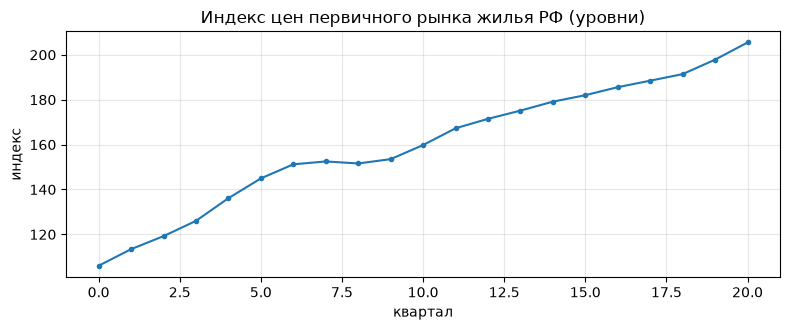

In [15]:
cal = dh.calibrate("realty_index.csv")
print(cal.summary())

plt.figure(figsize=(8, 3.4))
plt.plot(cal.prices, marker="o", ms=3)
plt.title("Индекс цен первичного рынка жилья РФ (уровни)")
plt.xlabel("квартал"); plt.ylabel("индекс"); plt.grid(alpha=.3)
plt.tight_layout(); save_fig("index")

## 2. Параметры модели

Все параметры собраны в объекте `Config`. Изменение — через `cfg.with_(...)`,
возвращающее новую конфигурацию; исходная не мутируется. Это позволяет
проводить анализ чувствительности и стресс-тесты без глобального состояния.

Базовый сценарий отражает действующий правовой режим долевого строительства:
средства дольщика находятся на счёте эскроу и при незавершении возвращаются
полностью (`eta_R = 1`), а банкротство отдельного застройщика не обрушивает
рыночный индекс жилья (`eta_S = 1`).

In [16]:
cfg = Config(sigma=float(cal.sigma_true))

print(f"sigma (десглаженная)     : {cfg.sigma:.4f}")
print(f"риск незавершения        : lambda={cfg.lam}, eta_R={cfg.eta_R}, eta_S={cfg.eta_S}")
print(f"инвестиционная стратегия : gamma_inv={cfg.gamma_inv}")
print(f"хеджирующий прокси       : rho_H={cfg.rho_H}")
print(f"контракт                 : возраст={cfg.x_age}, T={cfg.T}, alpha={cfg.alpha}, g={cfg.g}")
print(f"мера риска               : энтропийная, gamma={cfg.gamma_risk}")
print(f"смертность               : {dh.mortality.describe(cfg)}")

sigma (десглаженная)     : 0.0879
риск незавершения        : lambda=0.02, eta_R=1.0, eta_S=1.0
инвестиционная стратегия : gamma_inv=1.0
хеджирующий прокси       : rho_H=0.8
контракт                 : возраст=40, T=10, alpha=0.6, g=0.02
мера риска               : энтропийная, gamma=2.0
смертность               : Росстат 2023, оба пола, отбор 1.0; 10p40=0.9380; a_due=7.8791; P_ann=0.1206


## 3. Верификация вычислительной процедуры

Две независимые проверки. Во-первых, Монте-Карло против аналитической формулы
Блэка–Шоулза. Во-вторых, обученная методом глубокого хеджирования стратегия на
полном рынке (один фактор, чистое ГБД, `rho_H = 1`, `lambda = 0`) должна
воспроизводить ту же цену: совпадение подтверждает корректность не только
симуляции, но и самого метода оценки.

In [17]:
bs = dh.bs_call(1, 1, cfg.r0, cfg.sigma, 1.0)
mc, se = dh.mc_call(1, 1, cfg.r0, cfg.sigma, 1.0, lam=0.0)
mc_j, se_j = dh.mc_call(1, 1, cfg.r0, cfg.sigma, 1.0, lam=cfg.lam, eta=cfg.eta_S)

print(f"Блэк–Шоулз                : {bs:.5f}")
print(f"Монте-Карло (lambda=0)    : {mc:.5f} +/- {se:.5f}")
print(f"Монте-Карло (lambda={cfg.lam})  : {mc_j:.5f} +/- {se_j:.5f}")
if abs(cfg.eta_S - 1.0) < 1e-12:
    print("  (eta_S=1: скачок не влияет на цену актива — оценки совпадают;")
    print("   незавершение действует только через прекращение договора)")

Блэк–Шоулз                : 0.06396
Монте-Карло (lambda=0)    : 0.06390 +/- 0.00015
Монте-Карло (lambda=0.02)  : 0.06390 +/- 0.00015
  (eta_S=1: скачок не влияет на цену актива — оценки совпадают;
   незавершение действует только через прекращение договора)


In [18]:
dh_price = dh.verification.deep_hedging_complete_market(cfg, Tv=1.0, gamma=0.5)
print(f"Deep Hedging (полный рынок, out-of-sample): {dh_price:.5f}")
print(f"Блэк–Шоулз:                                 {bs:.5f}")
print(f"Относительная ошибка:                       {abs(dh_price - bs) / bs * 100:.2f}%")

Deep Hedging (полный рынок, out-of-sample): 0.06406
Блэк–Шоулз:                                 0.06396
Относительная ошибка:                       0.16%


## 4. Справедливая стоимость участия в прибыли

Основной расчёт на полной модели: стохастическая ставка, скачок незавершения,
базисный риск, смертность. Оба режима уплаты премии уравнены по принципу
эквивалентности.

Цена вычисляется как нетто-величина: из выплаты вычтен дисконтированный поток
будущих взносов, условный на дожитие и продолжение строительства. Поэтому для
режима ежегодной премии `pi` означает капитал, требуемый **сверх** будущих
взносов, и может быть отрицательным.

[single] pi(xi_alpha)=+0.85706  pi(xi_0)=+0.72265  V_part=0.13441
[annual] pi(xi_alpha)=+0.06914  pi(xi_0)=-0.01335  V_part=0.08249


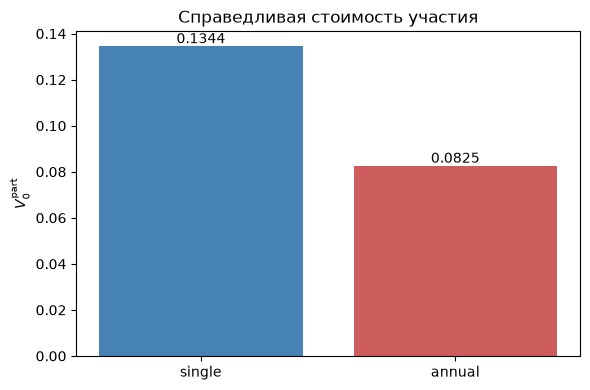

In [19]:
main = {}
for mode in (SINGLE, ANNUAL):
    res = dh.v_part(cfg, mode=mode, return_parts=True)
    main[mode] = res
    print(f"[{mode:6}] pi(xi_alpha)={res['pi_alpha']:+.5f}  "
          f"pi(xi_0)={res['pi_0']:+.5f}  V_part={res['V_part']:.5f}")

plt.figure(figsize=(6, 4))
vals = [main[m]["V_part"] for m in main]
plt.bar(list(main), vals, color=["steelblue", "indianred"])
for i, v in enumerate(vals):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")
plt.ylabel(r"$V_0^{\mathrm{part}}$")
plt.title("Справедливая стоимость участия")
plt.tight_layout(); save_fig("v_part")

### Качество хеджирующей стратегии

На неполном рынке распределение итогового капитала не вырождается в точку, а
сохраняет разброс, обусловленный нехеджируемыми рисками: скачком незавершения,
смертностью и базисным риском прокси. Именно этот остаточный риск и оценивается
выпуклой мерой.

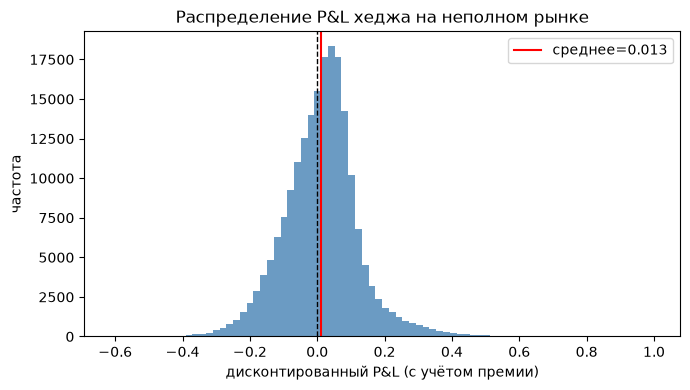

P&L: среднее=0.0125  ст.откл=0.1126  5%-квантиль=-0.1705


In [20]:
net = dh.train(cfg, mode=SINGLE)
_, pnl = dh.evaluate(net, cfg, mode=SINGLE, return_pnl=True)
X = pnl + main[SINGLE]["pi_alpha"]          # добавляем премию

plt.figure(figsize=(7, 4))
plt.hist(X, bins=80, color="steelblue", alpha=0.8)
plt.axvline(0, color="k", ls="--", lw=1)
plt.axvline(X.mean(), color="r", lw=1.5, label=f"среднее={X.mean():.3f}")
plt.xlabel("дисконтированный P&L (с учётом премии)"); plt.ylabel("частота")
plt.title("Распределение P&L хеджа на неполном рынке")
plt.legend(); plt.tight_layout(); save_fig("pnl")
print(f"P&L: среднее={X.mean():.4f}  ст.откл={X.std():.4f}  "
      f"5%-квантиль={np.percentile(X, 5):.4f}")

## 5. Анализ чувствительности

Исследуется именно справедливая стоимость участия, а не полная цена
обязательства: это обеспечивает сопоставимость с основным расчётом.

по gamma_risk:
  0.5: 0.12776
  1.0: 0.13002
  2.0: 0.13441
  5.0: 0.14663
по lambda:
  0.0: 0.16028
  0.02: 0.13441
  0.05: 0.10261
  0.1: 0.06397
по alpha:
  0.25: 0.05301
  0.5: 0.11030
  0.75: 0.17187
  1.0: 0.23777
по gamma_inv:
  0.25: 0.11825
  0.5: 0.12038
  0.75: 0.12532
  1.0: 0.13441


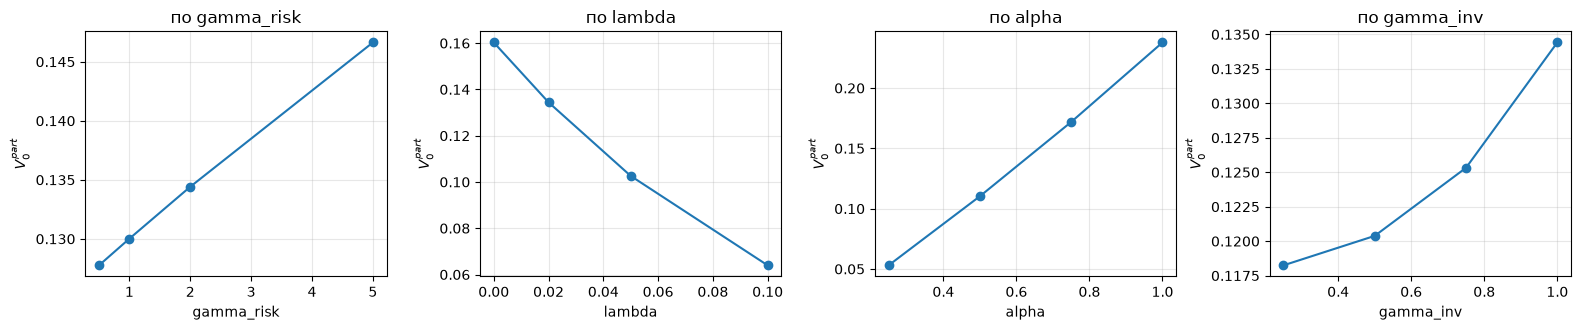

In [21]:
sens = []
for name, field, values in [
    ("gamma_risk", "gamma_risk", [0.5, 1.0, 2.0, 5.0]),
    ("lambda",     "lam",        [0.0, 0.02, 0.05, 0.10]),
    ("alpha",      "alpha",      [0.25, 0.5, 0.75, 1.0]),
    ("gamma_inv",  "gamma_inv",  [0.25, 0.5, 0.75, 1.0]),
]:
    print(f"по {name}:")
    for v in values:
        p = dh.v_part(cfg.with_(**{field: v}), mode=SINGLE)
        sens.append(dict(param=name, value=v, V_part=p))
        print(f"  {v}: {p:.5f}")

sens_df = pd.DataFrame(sens)
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
for k, nm in enumerate(sens_df.param.unique()):
    d = sens_df[sens_df.param == nm]
    ax[k].plot(d.value, d.V_part, "o-")
    ax[k].set_xlabel(nm); ax[k].set_ylabel(r"$V_0^{part}$")
    ax[k].set_title(f"по {nm}"); ax[k].grid(alpha=.3)
plt.tight_layout(); save_fig("sensitivity")

**Доля участия.** Зависимость от `alpha` близка к линейной: гарантийная часть
не зависит от `alpha` и сокращается в разности, оставляя опционную компоненту,
пропорциональную `alpha`. Это эмпирически подтверждает опционную декомпозицию
выплаты, полученную аналитически.

**Инвестиционная стратегия.** При малой доле в недвижимости стоимость участия
не обнуляется: безрисковая ставка выше гарантированной, поэтому фонд почти
наверняка обгоняет гарантию, и участие вырождается из опциона в почти
детерминированную выплату.

## 6. Стресс-тесты

  базовый               : 0.23777
  обвал цен (вол x2)    : 0.41226
  всплеск банкротств    : 0.12226
  распад корреляции     : 0.25918


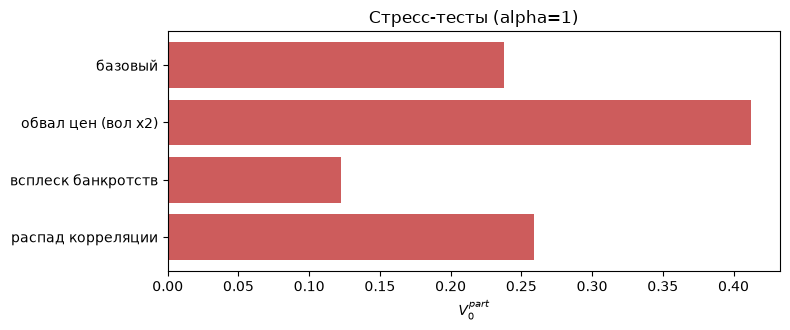

In [22]:
scenarios = {
    "базовый":            {},
    "обвал цен (вол x2)": {"sigma": 2 * cfg.sigma},
    "всплеск банкротств": {"lam": 0.10},
    "распад корреляции":  {"rho_H": 0.5},
}
stress = []
for name, kw in scenarios.items():
    p = dh.v_part(cfg.with_(alpha=1.0, **kw), mode=SINGLE)
    stress.append((name, p))
    print(f"  {name:22}: {p:.5f}")

plt.figure(figsize=(8, 3.4))
plt.barh([s[0] for s in stress], [s[1] for s in stress], color="indianred")
plt.xlabel(r"$V_0^{part}$"); plt.title("Стресс-тесты (alpha=1)")
plt.gca().invert_yaxis(); plt.tight_layout(); save_fig("stress")

## 7. Устойчивость к калибровке сглаживания

Оценка коэффициента сглаживания по короткому ряду неустойчива. Проверяем, как
это переносится на итоговую оценку.

  phi=0.300  sigma=0.0476  V_part=0.12106
  phi=0.500  sigma=0.0598  V_part=0.12383
  phi=0.671  sigma=0.0879  V_part=0.13441
  phi=0.800  sigma=0.1472  V_part=0.17330


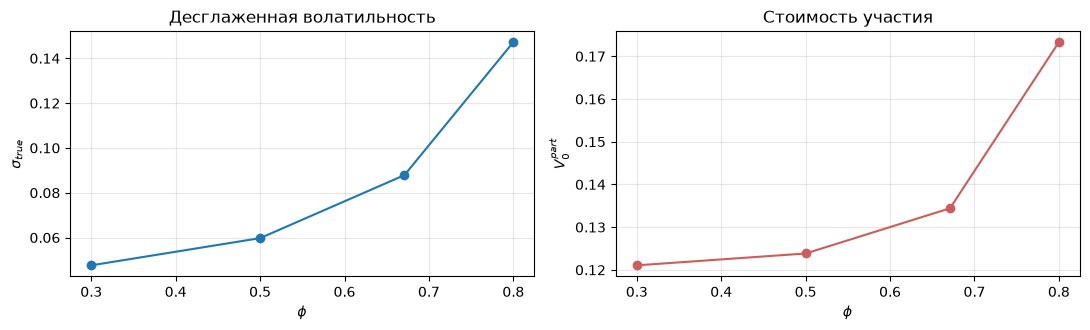

In [23]:
rows = []
for phi in [0.30, 0.50, cal.phi, 0.80]:
    _, st, _, _ = dh.geltner_unsmooth(cal.prices, phi=phi)
    sig = st * np.sqrt(4)
    p = dh.v_part(cfg.with_(sigma=sig), mode=SINGLE)
    rows.append(dict(phi=round(phi, 3), sigma_true=sig, V_part=p))
    print(f"  phi={phi:.3f}  sigma={sig:.4f}  V_part={p:.5f}")

phi_df = pd.DataFrame(rows)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(phi_df.phi, phi_df.sigma_true, "o-")
ax[0].set_xlabel(r"$\phi$"); ax[0].set_ylabel(r"$\sigma_{true}$")
ax[0].set_title("Десглаженная волатильность"); ax[0].grid(alpha=.3)
ax[1].plot(phi_df.phi, phi_df.V_part, "o-", color="indianred")
ax[1].set_xlabel(r"$\phi$"); ax[1].set_ylabel(r"$V_0^{part}$")
ax[1].set_title("Стоимость участия"); ax[1].grid(alpha=.3)
plt.tight_layout(); save_fig("phi")

## 8. Эффект риска незавершения при действующем режиме эскроу

**На каком объекте считать.** На путях, где стройка не завершена, выплата равна
$\eta_R C_\theta D(\theta)$ одинаково при $\alpha>0$ и при $\alpha=0$. Поэтому
в разности $V_0^{part}=\pi(\xi_\alpha)-\pi(\xi_0)$ эта компонента сокращается:
точно при линейном ценообразовании и почти точно при энтропийной мере.
Величина и момент возврата влияют на **полную цену обязательства**, а не на
стоимость участия. Ниже приводятся обе величины.

In [24]:
configs = [
    ("1. lambda=0 (риска нет)",       cfg.with_(lam=0.0),   False),
    ("2. eta_R=1, возврат в theta",   cfg.with_(eta_R=1.0), False),
    ("3. eta_R=1, возврат при выплате", cfg.with_(eta_R=1.0), True),
    ("4. eta_R=0.9 (сверх лимита)",   cfg.with_(eta_R=0.9), False),
]
rows = []
for label, c, at_mat in configs:
    r = dh.v_part(c, mode=SINGLE, return_at_maturity=at_mat, return_parts=True)
    rows.append(dict(конфигурация=label, **{"pi(xi_alpha)": r["pi_alpha"],
                                            "V_part": r["V_part"]}))
dec = pd.DataFrame(rows)
display(dec.round(5))

v1, v2 = dec.V_part[0], dec.V_part[1]
p2, p3, p4 = dec["pi(xi_alpha)"][1], dec["pi(xi_alpha)"][2], dec["pi(xi_alpha)"][3]
print(f"\nУТРАТА ОПЦИОНА (V_part, строки 1-2)      : {v2 - v1:+.4f}"
      f"  ({(v2 - v1) / v1 * 100:+.1f}%)")
print(f"БЕСПРОЦЕНТНЫЙ ЭСКРОУ (pi, строки 2-3)    : {p2 - p3:+.4f}")
print(f"КРЕДИТНЫЙ РИСК БАНКА (pi, строки 2-4)    : {p4 - p2:+.4f}")
print("\nВывод: при полном возврате номинала участие всё равно обесценивается —")
print("убыток даёт утрата опционной компоненты, а не потеря вложенных средств.")

,конфигурация,pi(xi_alpha),V_part
0,1. lambda=0 (риска нет),0.87205,0.16028
1,"2. eta_R=1, возврат в theta",0.85706,0.13441
2,"3. eta_R=1, возврат при выплате",0.83297,0.14124
3,4. eta_R=0.9 (сверх лимита),0.84606,0.13754



УТРАТА ОПЦИОНА (V_part, строки 1-2)      : -0.0259  (-16.1%)
БЕСПРОЦЕНТНЫЙ ЭСКРОУ (pi, строки 2-3)    : +0.0241
КРЕДИТНЫЙ РИСК БАНКА (pi, строки 2-4)    : -0.0110

Вывод: при полном возврате номинала участие всё равно обесценивается —
убыток даёт утрата опционной компоненты, а не потеря вложенных средств.


## 9. Контроль учёта потока взносов

Поток взносов входит одинаково в $\pi(\xi_\alpha)$ и $\pi(\xi_0)$. Проверяем,
насколько он сокращается в разности при нелинейной мере риска.

In [25]:
v_with = dh.v_part(cfg, mode=ANNUAL)

import deep_hedging.contract as contract
_orig = contract.premium_flow
contract.premium_flow = lambda c, D, th, K, m: torch.zeros(D.shape[0], device=D.device)
try:
    v_without = dh.v_part(cfg, mode=ANNUAL)
finally:
    contract.premium_flow = _orig

print(f"V_part (annual) с учётом потока взносов : {v_with:.4f}")
print(f"V_part (annual) без учёта потока взносов: {v_without:.4f}")
print(f"относительное расхождение              : "
      f"{abs(v_with - v_without) / abs(v_without) * 100:.2f}%")

V_part (annual) с учётом потока взносов : 0.0825
V_part (annual) без учёта потока взносов: 0.0930
относительное расхождение              : 11.32%


## 10. Сводка результатов

In [26]:
print("=" * 62)
print("СВОДКА РЕЗУЛЬТАТОВ")
print("=" * 62)
print(f"Данные      : {cal.summary()}")
print(f"Рынок       : lambda={cfg.lam}, eta_R={cfg.eta_R}, eta_S={cfg.eta_S}, "
      f"rho_H={cfg.rho_H}")
print(f"Стратегия   : gamma_inv={cfg.gamma_inv}")
print(f"Мера риска  : энтропийная, gamma={cfg.gamma_risk}")
print(f"Смертность  : {dh.mortality.describe(cfg)}")
print("-" * 62)
for m, r in main.items():
    print(f"{m:7}: V_part={r['V_part']:.5f}   "
          f"(pi_a={r['pi_alpha']:+.5f}, pi_0={r['pi_0']:+.5f})")
print("-" * 62)
print(f"Верификация : Deep Hedging vs Блэк–Шоулз, ошибка "
      f"{abs(dh_price - bs) / bs * 100:.2f}%")
print("Эти числа и графики переносятся в главу 4.")

СВОДКА РЕЗУЛЬТАТОВ
Данные      : реальные данные, 21 наблюдений; phi=0.671; sigma 0.0437 -> 0.0879 (x2.01); mu=0.1324
Рынок       : lambda=0.02, eta_R=1.0, eta_S=1.0, rho_H=0.8
Стратегия   : gamma_inv=1.0
Мера риска  : энтропийная, gamma=2.0
Смертность  : Росстат 2023, оба пола, отбор 1.0; 10p40=0.9380; a_due=7.8791; P_ann=0.1206
--------------------------------------------------------------
single : V_part=0.13441   (pi_a=+0.85706, pi_0=+0.72265)
annual : V_part=0.08249   (pi_a=+0.06914, pi_0=-0.01335)
--------------------------------------------------------------
Верификация : Deep Hedging vs Блэк–Шоулз, ошибка 0.16%
Эти числа и графики переносятся в главу 4.
